In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import Normalizer
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

In [5]:
data = pd.read_csv('dataset.csv')
data = data.drop('prov', axis=1)
data

,mag,depth,rad,lat,lon,prov_enco
0,3.6,10,74,-3.92,133.71,1
1,2.6,164,3,1.49,99.64,2
2,4.5,182,165,-4.60,129.69,3
3,3.2,10,116,-8.50,107.82,4
4,5.0,11,129,1.96,126.60,5
...,...,...,...,...,...,...
1934,3.2,10,29,4.54,96.59,9
1935,2.9,10,107,1.78,122.85,15
1936,4.4,386,187,-6.47,127.97,14
1937,3.1,24,69,1.39,126.93,5


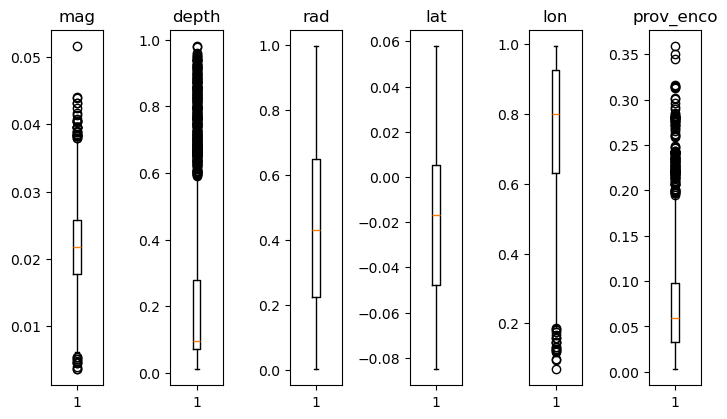

In [6]:
scaler = Normalizer()
dataScaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

plt.figure(figsize=(12, 8))
for i, column in enumerate (dataScaled.columns, 1):
    plt.subplot(2, 10, i)
    plt.boxplot(dataScaled[column])
    plt.title(column)
plt.tight_layout()
plt.show()

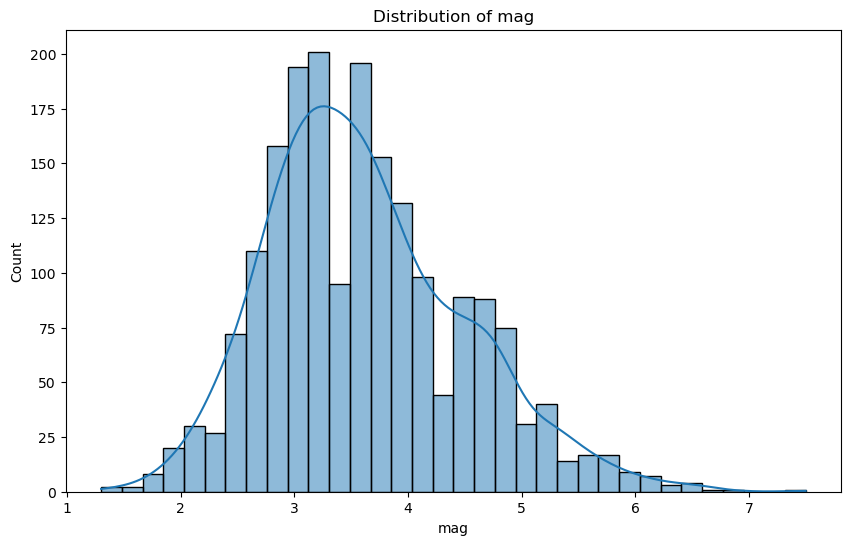

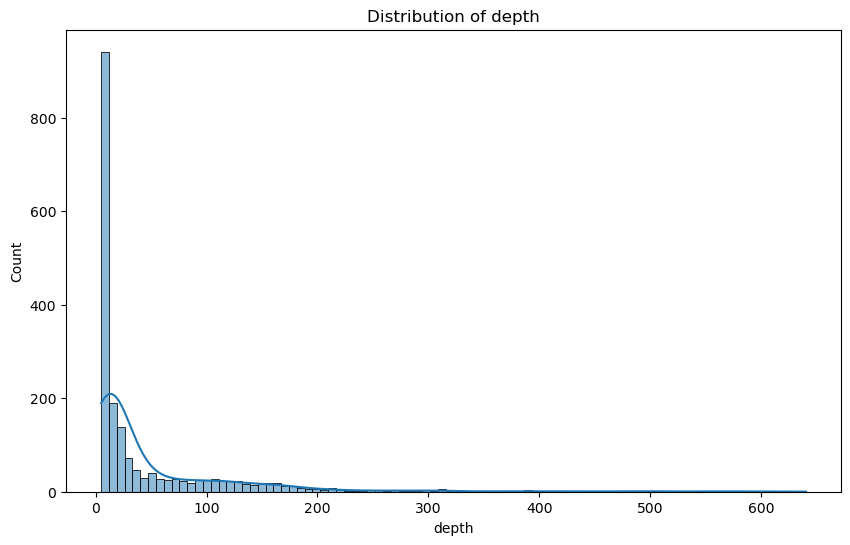

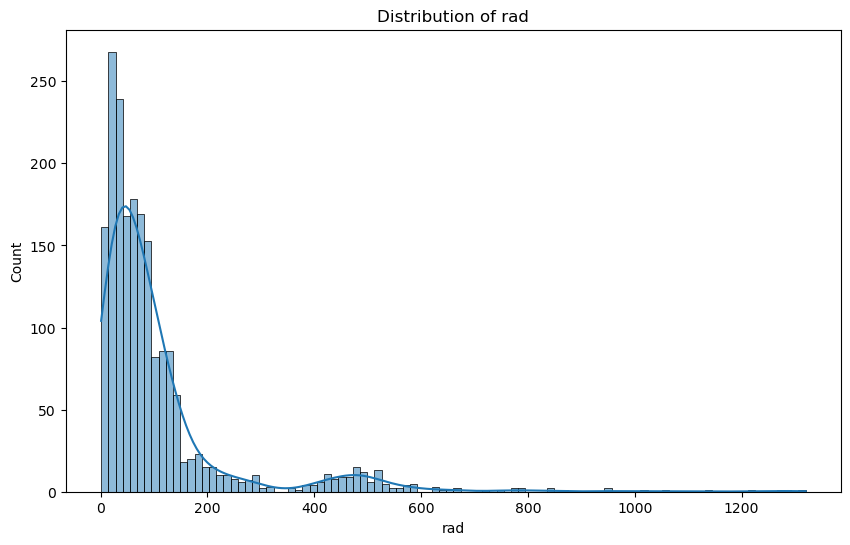

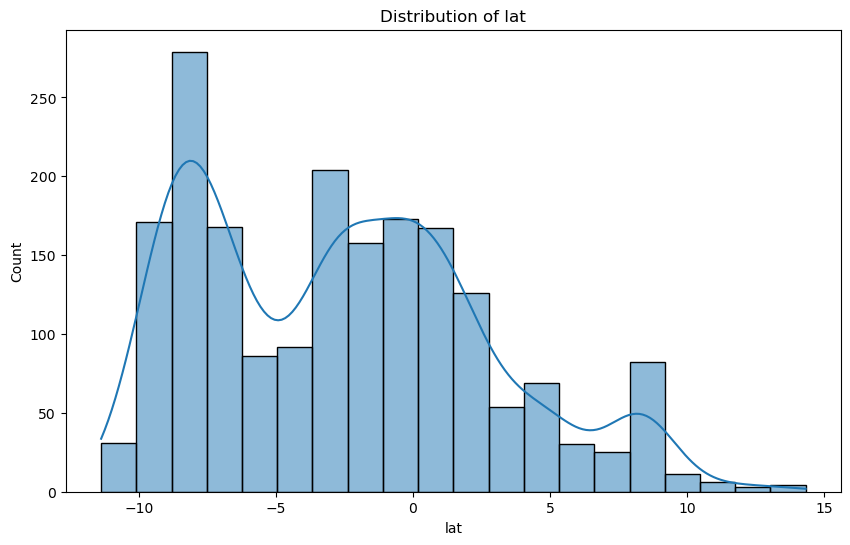

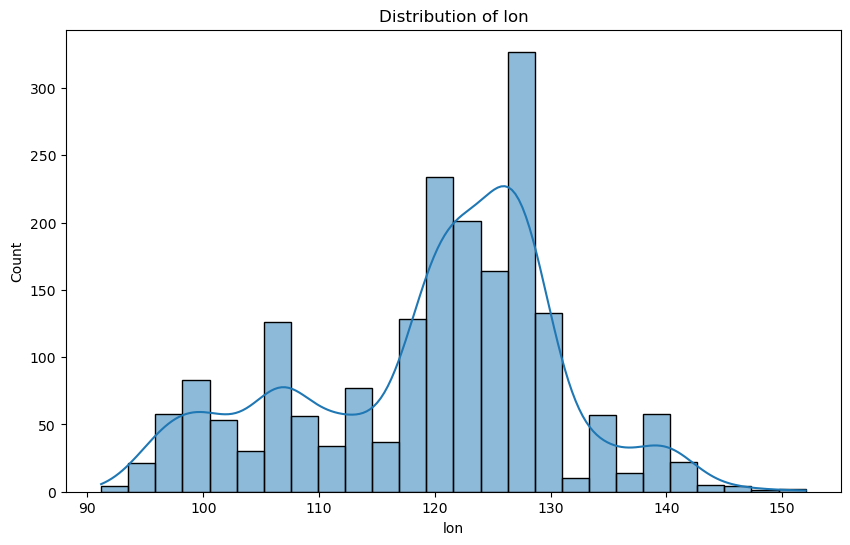

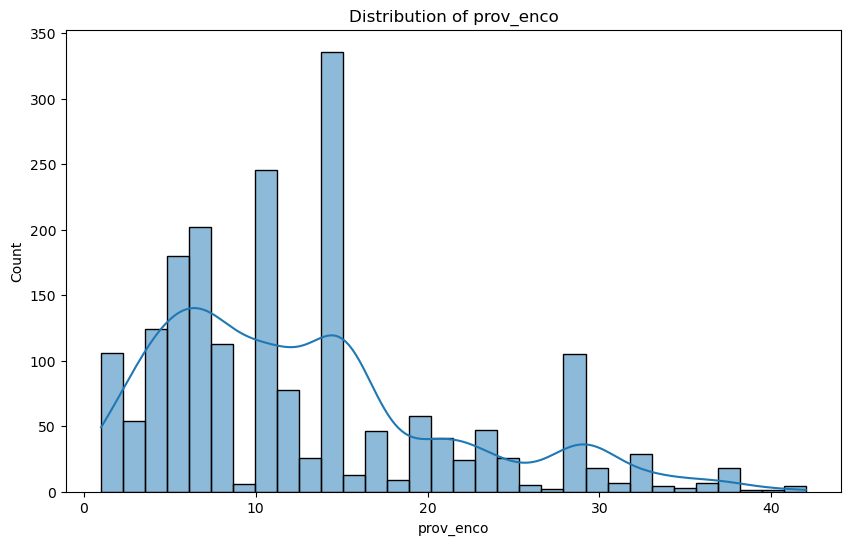

In [7]:
for column in dataScaled.columns[:6]:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

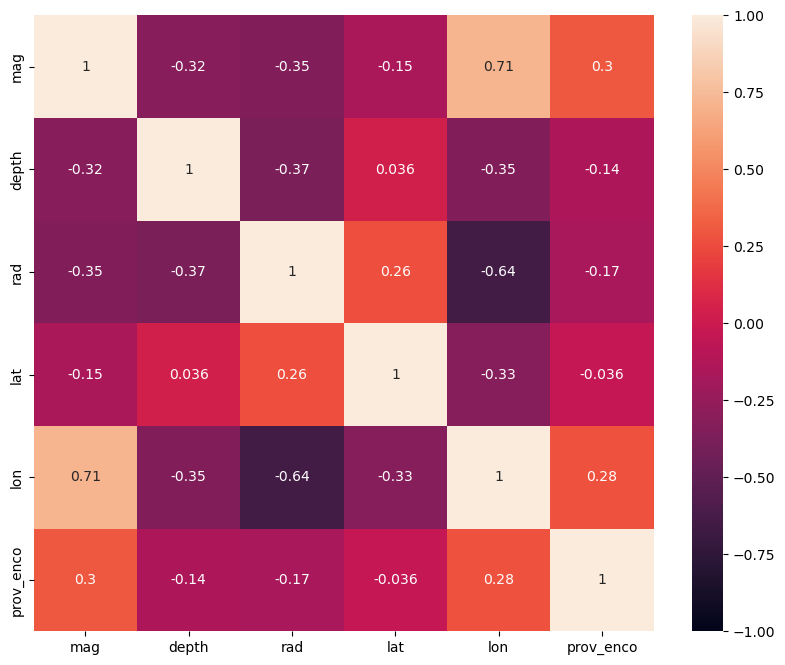

In [8]:
correlation = dataScaled.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, vmin=-1, vmax=1)
plt.show()

C:\ProgramData\anaconda3\envs\test\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\anaconda3\envs\test\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\anaconda3\envs\test\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\anaconda3\envs\test\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\ProgramData\a

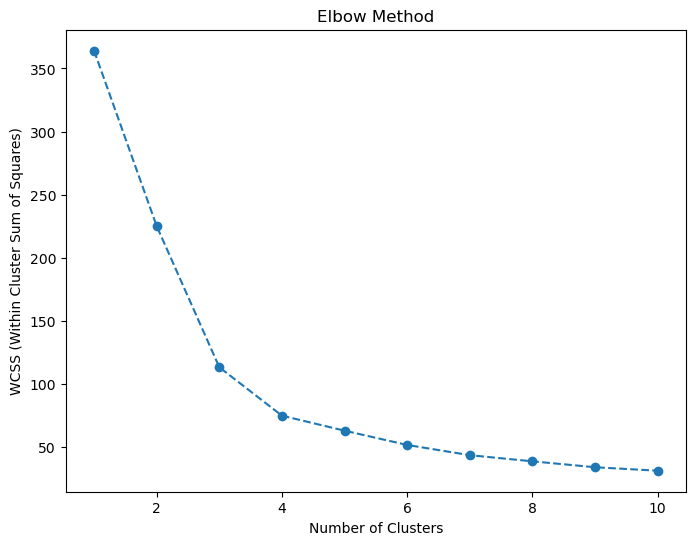

In [9]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(dataScaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

In [10]:
cluster_knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
cluster_knee.elbow

4

In [11]:
kmeans = KMeans(n_clusters=cluster_knee.elbow, random_state=42)
predict = kmeans.fit_predict(dataScaled)
kmeans.cluster_centers_

C:\ProgramData\anaconda3\envs\test\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


array([[ 0.02532523,  0.13430847,  0.23763445, -0.0282763 ,  0.94087808,
         0.09876001],
       [ 0.01264186,  0.11292006,  0.91554122,  0.00260389,  0.32854085,
         0.04305504],
       [ 0.01710285,  0.72043824,  0.26381528, -0.01744121,  0.57787732,
         0.05986954],
       [ 0.02336856,  0.1182976 ,  0.61007037, -0.01959355,  0.75885694,
         0.0815039 ]])

In [12]:
data['cluster'] = predict
data['cluster'].value_counts()

cluster
0    707
3    657
2    340
1    235
Name: count, dtype: int64

In [13]:
avg = silhouette_score(dataScaled, predict)
avg

0.4709257765307513